  
### RECOMMENDATION SYSTEMS - "TMDB Movies Dataset"

### Overview
Content-based movie recommendation using TMDB dataset and text similarity techniques.

### Dataset Description
The dataset used for this project is the "TMDB 500 Movie Dataset" which is available on Kaggle.

Kaggle Link: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata

Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import ast

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

Loading Dataset 

In [2]:
df = pd.read_csv("D:/tmdb_5000_movies.csv")
print(df.head())

      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "nam

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

Missing Values

In [4]:
print(df.isnull().sum())

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64


In [5]:
df.dropna(inplace=True)

Duplicates

In [6]:
print(df.duplicated().sum())

0


Selecting Required Columns

In [7]:
df = df[['id','original_title','overview','genres','keywords']]
df.rename(columns={'id':'movie_id','original_title':'title'}, inplace=True)

Visualization

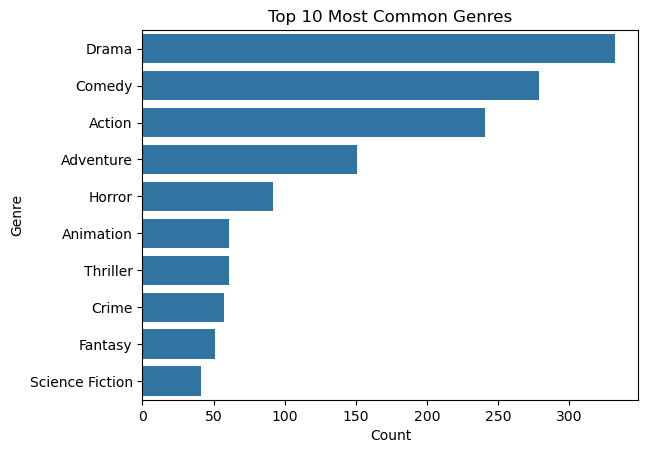

In [9]:
#Countplot
df['first_genre'] = df['genres'].apply(
    lambda x: ast.literal_eval(x)[0]['name'] if len(ast.literal_eval(x)) > 0 else "Unknown"
)

sns.countplot(y=df['first_genre'], order=df['first_genre'].value_counts().index[:10])
plt.title("Top 10 Most Common Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

Converting JSON columns

In [10]:
def convert(text):
    L = []
    for i in ast.literal_eval(text):
        L.append(i['name'])
    return L

df['genres'] = df['genres'].apply(convert)
df['keywords'] = df['keywords'].apply(convert)

Processing Overview column, Removing Spaces and combining them

In [11]:
df['overview'] = df['overview'].apply(lambda x: x.split() if isinstance(x,str) else x)

In [12]:
#Removing spaces
df['genres'] = df['genres'].apply(lambda x: [i.replace(" ", "") for i in x])
df['keywords'] = df['keywords'].apply(lambda x: [i.replace(" ", "") for i in x])

In [13]:
#Combining columns as tags
df['tags'] = df['overview'] + df['genres'] + df['keywords']

Final Dataset

In [14]:
new_df = df[['movie_id','title','tags']]
new_df

,movie_id,title,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili..."
...,...,...,...
4773,2292,Clerks,"[Convenience, and, video, store, clerks, Dante..."
4781,255266,Dry Spell,"[Sasha, tries, to, get, her, soon-to-be, ex, h..."
4791,157185,Tin Can Man,"[Recently, dumped, by, his, girlfirend, for, a..."
4796,14337,Primer,"[Friends/fledgling, entrepreneurs, invent, a, ..."


Converting tags to string

In [15]:
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x))
new_df['tags'] = new_df['tags'].apply(lambda x: x.lower())

print(new_df.head())

   movie_id                                     title  \
0     19995                                    Avatar   
1       285  Pirates of the Caribbean: At World's End   
2    206647                                   Spectre   
3     49026                     The Dark Knight Rises   
4     49529                               John Carter   

                                                tags  
0  in the 22nd century, a paraplegic marine is di...  
1  captain barbossa, long believed to be dead, ha...  
2  a cryptic message from bond’s past sends him o...  
3  following the death of district attorney harve...  
4  john carter is a war-weary, former military ca...  


C:\Users\Home\AppData\Local\Temp\ipykernel_7612\3230782234.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x))
C:\Users\Home\AppData\Local\Temp\ipykernel_7612\3230782234.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(lambda x: x.lower())


Count vectorizer

In [16]:
cv = CountVectorizer(max_features=5000, stop_words='english')
vectors_cv = cv.fit_transform(new_df['tags']).toarray()

similarity_cv = cosine_similarity(vectors_cv)
print(similarity_cv)

[[1.         0.0877058  0.05751973 ... 0.         0.0541332  0.02531848]
 [0.0877058  1.         0.06558258 ... 0.048795   0.         0.        ]
 [0.05751973 0.06558258 1.         ... 0.         0.         0.        ]
 ...
 [0.         0.048795   0.         ... 1.         0.         0.04225771]
 [0.0541332  0.         0.         ... 0.         1.         0.        ]
 [0.02531848 0.         0.         ... 0.04225771 0.         1.        ]]


TF-IDF

In [17]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
vectors_tfidf = tfidf.fit_transform(new_df['tags']).toarray()

similarity_tfidf = cosine_similarity(vectors_tfidf)
print(similarity_tfidf)

[[1.         0.01963479 0.01095998 ... 0.         0.03668556 0.00616543]
 [0.01963479 1.         0.01262129 ... 0.01331849 0.         0.        ]
 [0.01095998 0.01262129 1.         ... 0.         0.         0.        ]
 ...
 [0.         0.01331849 0.         ... 1.         0.         0.02830049]
 [0.03668556 0.         0.         ... 0.         1.         0.        ]
 [0.00616543 0.         0.         ... 0.02830049 0.         1.        ]]


Heatmap to understand which movies are highly similar

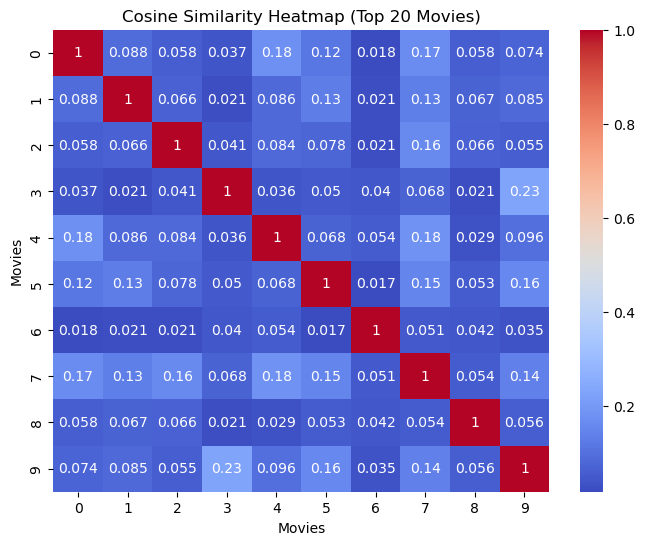

In [20]:
subset_size = 10 
subset_similarity = similarity_cv[:subset_size, :subset_size]

plt.figure(figsize=(8,6))
sns.heatmap(subset_similarity, annot=True, cmap='coolwarm')

plt.title("Cosine Similarity Heatmap (Top 20 Movies)")
plt.xlabel("Movies")
plt.ylabel("Movies")

plt.show()

Recommendation Function

In [21]:
def recommend(movie, similarity):
    
    if movie not in new_df['title'].values:
        print("Movie not found!")
        return
    
    index = new_df[new_df['title'] == movie].index[0]
    
    distances = similarity[index]
    
    movie_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]
    
    print(f"\n🎬 Recommendations for '{movie}':\n")
    
    for i in movie_list:
        print(new_df.iloc[i[0]].title, " (Score:", round(i[1], 2), ")")

In [22]:
# Using CountVectorizer
recommend("Avatar", similarity_cv)

# Using TF-IDF
recommend("Avatar", similarity_tfidf)


🎬 Recommendations for 'Avatar':

Ender's Game  (Score: 0.24 )
Battle: Los Angeles  (Score: 0.23 )
Aliens vs Predator: Requiem  (Score: 0.23 )
Jupiter Ascending  (Score: 0.23 )
Apollo 18  (Score: 0.22 )

🎬 Recommendations for 'Avatar':

Battle: Los Angeles  (Score: 0.19 )
Apollo 18  (Score: 0.17 )
Ender's Game  (Score: 0.14 )
Edge of Tomorrow  (Score: 0.13 )
Galaxina  (Score: 0.13 )


Recommendation visualization

In [23]:
def recommend_with_plot(movie, similarity):
    
    if movie not in new_df['title'].values:
        print("Movie not found!")
        return
    
    index = new_df[new_df['title'] == movie].index[0]
    
    distances = similarity[index]
    
    movie_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]
    
    names = [new_df.iloc[i[0]].title for i in movie_list]
    scores = [i[1] for i in movie_list]
    
    plt.barh(names, scores)
    plt.title(f"Top Recommendations for {movie}")
    plt.xlabel("Similarity Score")
    plt.show()

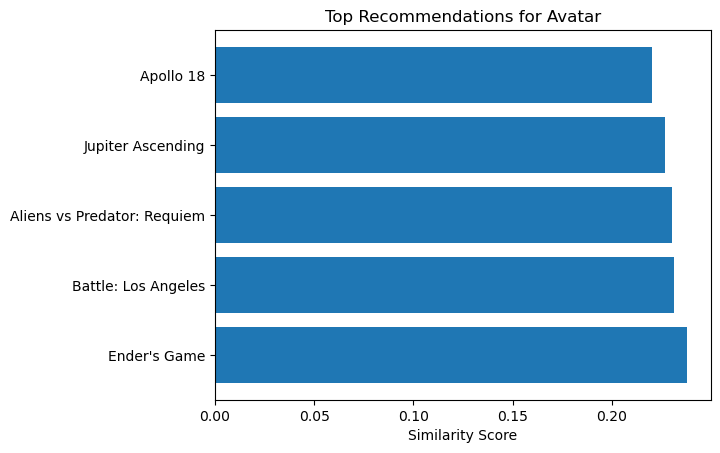

In [24]:
recommend_with_plot("Avatar", similarity_cv)